# 04 - Calibration and Model Governance

A dedicated calibration block fits Platt scaling after model selection. The policy and final test blocks are not used to fit the calibrator.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
ART = ROOT / 'artifacts'
FIG = ROOT / 'reports' / 'figures'
pd.set_option('display.max_columns', 100)


In [2]:
pd.read_csv(ART / 'calibration_fit_summary.csv')

Out[0]: 
  version   roc_auc    pr_auc  pr_auc_lift     brier  brier_skill  log_loss  \
0     raw  0.951662  0.743076   702.801257  0.004343    -3.111527  0.046590   
1   platt  0.951662  0.743076   702.801257  0.000370     0.649470  0.002724   

   precision    recall        f1  balanced_accuracy       mcc  threshold  \
0   0.550000  0.733333  0.628571           0.866349  0.634647        0.5   
1   0.954545  0.700000  0.807692           0.849982  0.817267        0.5   

   alerts  prevalence  
0      40    0.001057  
1      22    0.001057  


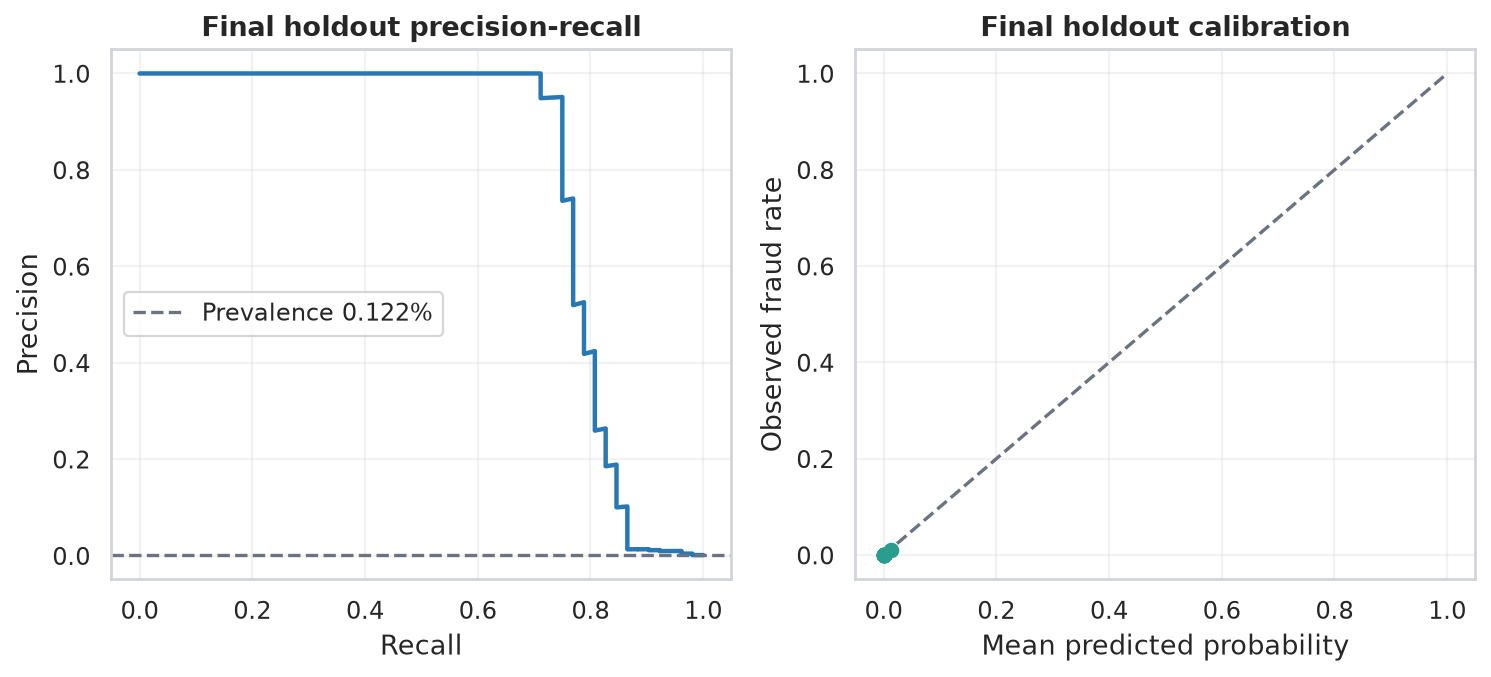

In [3]:
display(Image(filename=str(FIG / '05_final_pr_calibration.png')))

In [4]:
pd.read_csv(ART / 'temporal_split_summary.csv')

Out[0]: 
     partition    rows  frauds  fraud_rate  start_hour   end_hour
0        train  156049     332    0.002128    0.000000  30.160000
1   validation   28372      18    0.000634   30.161111  35.142222
2  calibration   28374      30    0.001057   35.142500  38.693889
3       policy   28374      41    0.001445   38.694167  42.033333
4         test   42557      52    0.001222   42.033611  47.997778


Production monitoring should track prevalence, calibration intercept/slope, PR-AUC at capacity, amount distribution and score drift. Recalibration must use labels available after the verification delay.